In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score,classification_report,recall_score, roc_curve,precision_score, auc

from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

In [2]:
df = pd.read_csv("Food_Delivery_Time_Prediction.csv")
df.head()

,Order_ID,Customer_Location,Restaurant_Location,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount
0,ORD0001,"(17.030479, 79.743077)","(12.358515, 85.100083)",1.57,Rainy,Medium,4,Medium,Afternoon,Car,4.1,3.0,26.22,1321.10,81.54
1,ORD0002,"(15.398319, 86.639122)","(14.174874, 77.025606)",21.32,Cloudy,Medium,8,Low,Night,Car,4.5,4.2,62.61,152.21,29.02
2,ORD0003,"(15.687342, 83.888808)","(19.594748, 82.048482)",6.95,Snowy,Medium,9,High,Night,Bike,3.3,3.4,48.43,1644.38,64.17
3,ORD0004,"(20.415599, 78.046984)","(16.915906, 78.278698)",13.79,Cloudy,Low,2,Medium,Evening,Bike,3.2,3.7,111.63,541.25,79.23
4,ORD0005,"(14.786904, 78.706532)","(15.206038, 86.203182)",6.72,Rainy,High,6,Low,Night,Bike,3.5,2.8,32.38,619.81,2.34


In [3]:
print(df.isnull().sum())


Order_ID                      0
Customer_Location             0
Restaurant_Location           0
Distance                      0
Weather_Conditions            0
Traffic_Conditions            0
Delivery_Person_Experience    0
Order_Priority                0
Order_Time                    0
Vehicle_Type                  0
Restaurant_Rating             0
Customer_Rating               0
Delivery_Time                 0
Order_Cost                    0
Tip_Amount                    0
dtype: int64


In [5]:
def haversine(loc1, loc2):
    """
    Calculates the great-circle distance between two points on Earth.
    """
    try:
        lat1, lon1 = map(float, loc1.split(','))
        lat2, lon2 = map(float, loc2.split(','))
        
        # Convert to radians
        lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
        
        dlon = lon2 - lon1
        dlat = lat2 - lat1
        a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
        c = 2 * asin(sqrt(a))
        r = 6371 # Radius of Earth in KM
        return c * r
    except:
        return 0

# Apply Haversine
df['Calculated_Distance'] = df.apply(lambda x: haversine(x['Customer_Location'], x['Restaurant_Location']), axis=1)
threshold = df['Delivery_Time'].median()
df['Delivery_Status'] = (df['Delivery_Time'] > threshold).astype(int)

In [6]:
le = LabelEncoder()

categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [8]:
scaler = StandardScaler()

numerical_cols = ['Distance', 'Delivery_Time']
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

In [9]:
X = df.drop(['Delivery_Status'], axis=1)
y = df['Delivery_Status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
nb = GaussianNB()
nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print(confusion_matrix(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 1.0
[[19  0]
 [ 0 21]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        21

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



In [12]:
param_grid = {'n_neighbors': range(3, 15)}

grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
grid.fit(X_train, y_train)

knn = grid.best_estimator_

y_pred_knn = knn.predict(X_test)

print("Best K:", grid.best_params_)
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print(confusion_matrix(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

Best K: {'n_neighbors': 11}
KNN Accuracy: 0.55
[[11  8]
 [10 11]]
              precision    recall  f1-score   support

           0       0.52      0.58      0.55        19
           1       0.58      0.52      0.55        21

    accuracy                           0.55        40
   macro avg       0.55      0.55      0.55        40
weighted avg       0.55      0.55      0.55        40



In [13]:
param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10]
}

grid_dt = GridSearchCV(DecisionTreeClassifier(), param_grid, cv=5)
grid_dt.fit(X_train, y_train)

dt = grid_dt.best_estimator_

y_pred_dt = dt.predict(X_test)

print("Best Params:", grid_dt.best_params_)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))


Best Params: {'max_depth': 3, 'min_samples_split': 2}
Decision Tree Accuracy: 0.975
[[19  0]
 [ 1 20]]
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        19
           1       1.00      0.95      0.98        21

    accuracy                           0.97        40
   macro avg       0.97      0.98      0.97        40
weighted avg       0.98      0.97      0.98        40



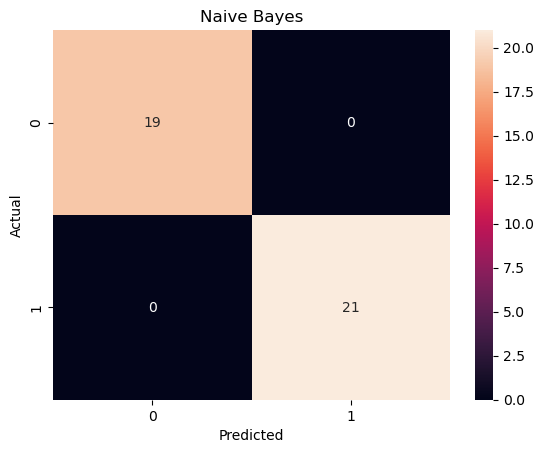

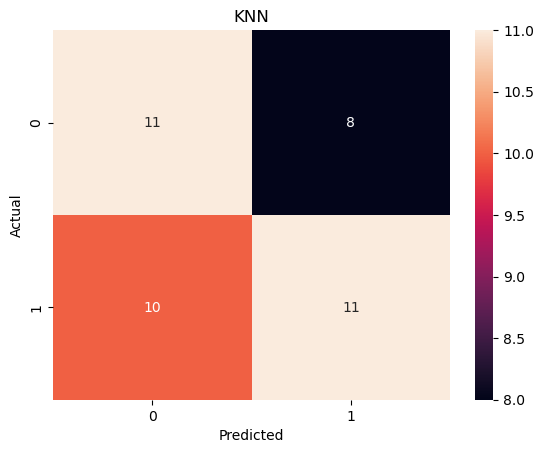

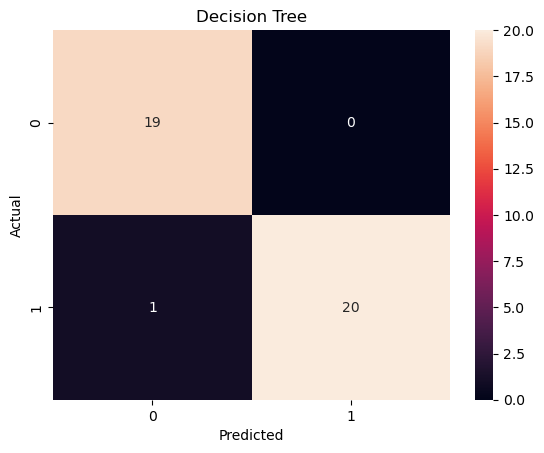

In [14]:
def plot_confusion(y_test, y_pred, title):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

plot_confusion(y_test, y_pred_nb, "Naive Bayes")
plot_confusion(y_test, y_pred_knn, "KNN")
plot_confusion(y_test, y_pred_dt, "Decision Tree")

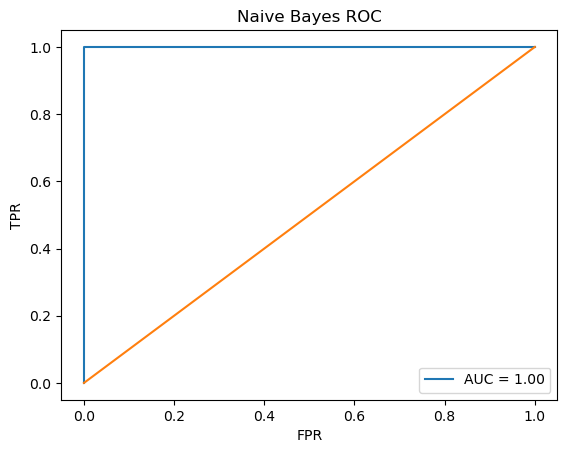

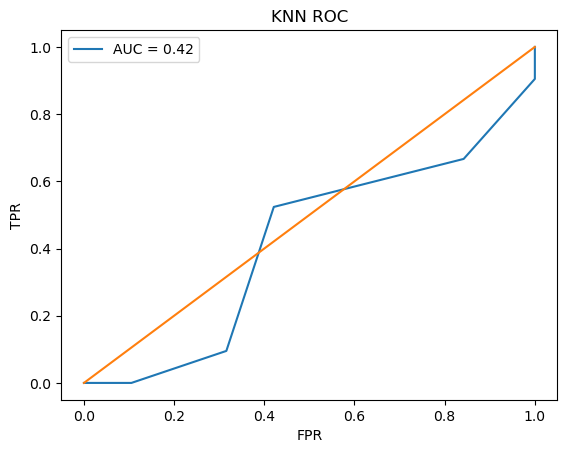

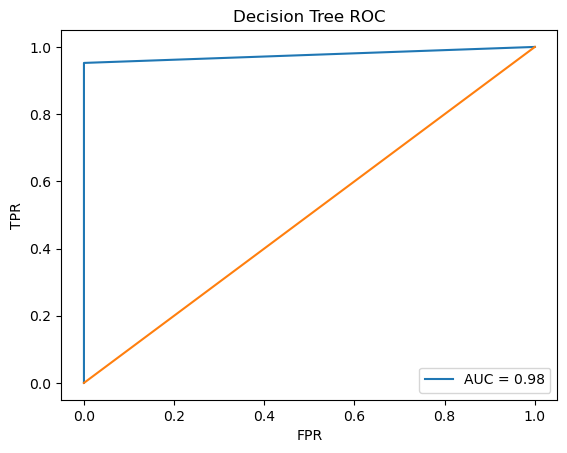

In [15]:
def plot_roc(model, X_test, y_test, title):
    y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
    plt.plot([0,1],[0,1])
    plt.title(title)
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.legend()
    plt.show()

plot_roc(nb, X_test, y_test, "Naive Bayes ROC")
plot_roc(knn, X_test, y_test, "KNN ROC")
plot_roc(dt, X_test, y_test, "Decision Tree ROC")

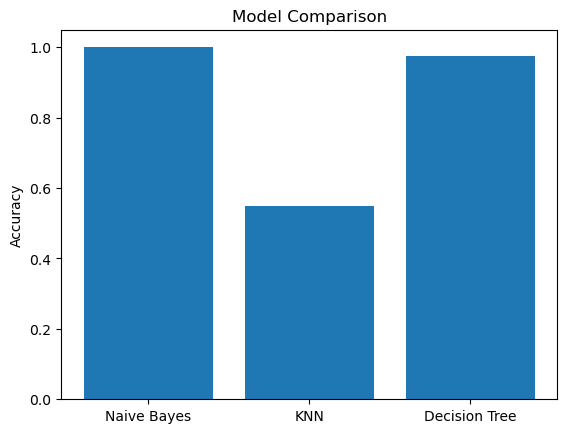

In [16]:
models = ['Naive Bayes', 'KNN', 'Decision Tree']
accuracies = [
    accuracy_score(y_test, y_pred_nb),
    accuracy_score(y_test, y_pred_knn),
    accuracy_score(y_test, y_pred_dt)
]

plt.bar(models, accuracies)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()

In [23]:
# Store results
results = []

results.append({
    'Model': 'Naive Bayes',
    'Accuracy': accuracy_score(y_test, y_pred_nb),
    'Precision': precision_score(y_test, y_pred_nb),
    'Recall': recall_score(y_test, y_pred_nb),
    'F1 Score': f1_score(y_test, y_pred_nb)
})

results.append({
    'Model': 'KNN',
    'Accuracy': accuracy_score(y_test, y_pred_knn),
    'Precision': precision_score(y_test, y_pred_knn),
    'Recall': recall_score(y_test, y_pred_knn),
    'F1 Score': f1_score(y_test, y_pred_knn)
})

results.append({
    'Model': 'Decision Tree',
    'Accuracy': accuracy_score(y_test, y_pred_dt),
    'Precision': precision_score(y_test, y_pred_dt),
    'Recall': recall_score(y_test, y_pred_dt),
    'F1 Score': f1_score(y_test, y_pred_dt)
})

results_df = pd.DataFrame(results)

print(results_df)

           Model  Accuracy  Precision    Recall  F1 Score
0    Naive Bayes     1.000   1.000000  1.000000   1.00000
1            KNN     0.550   0.578947  0.523810   0.55000
2  Decision Tree     0.975   1.000000  0.952381   0.97561
